# 01 — Exploration des données MovieLens 32M
## Objectif

Explorer et comprendre le dataset MovieLens 32M avant la construction du système de recommandation.
Cette analyse porte principalement sur :

- les utilisateurs ;
- les films ;
- les évaluations ;
- les tags ;
- la distribution des interactions ;
- la sparsité de la matrice utilisateur-film.

L'objectif est d'identifier les caractéristiques du dataset qui influenceront les choix d'architecture et de modèles du système de recommandation.

# Structure des fichiers sources - MovieLens 32M

### `movies.csv` (Les métadonnées des films)
Ce fichier répertorie l'ensemble des films disponibles dans le jeu de données.

* **Colonnes :** `movieId`, `title`, `genres`
* **Détails :**
  * `movieId` : L'identifiant unique du film (la clé qui lie ce fichier aux autres).
  * `title` : Le titre officiel du film, incluant généralement l'année de sortie entre parenthèses (ex: *Toy Story (1995)*).
  * `genres` : Une liste de genres associés au film, séparés par un tube `|` (ex: *Animation|Children|Comedy*).

---

### `ratings.csv` (Les interactions / notes)
C'est ce fichier qui contient les 32 millions de lignes de notations des films

* **Colonnes :** `userId`, `movieId`, `rating`, `timestamp`
* **Détails :**
  * `userId` : L'identifiant unique anonymisé de l'utilisateur.
  * `movieId` : L'identifiant du film qui a été noté.
  * `rating` : La note attribuée, sur une échelle de **0.5 à 5.0** (avec des incréments de 0.5).
  * `timestamp` : La date et l'heure auxquelles la note a été soumise, exprimées en secondes depuis l'époque Unix (1er janvier 1970).

---

### `tags.csv` (Les mots-clés des utilisateurs)
Ce fichier contient les "tags" textuels que les utilisateurs ont librement appliqués aux films (environ 2 millions d'applications de tags).

* **Colonnes :** `userId`, `movieId`, `tag`, `timestamp`
* **Détails :**
  * `tag` : Un mot ou une phrase courte écrite par l'utilisateur pour décrire un aspect du film.
  * Les autres colonnes servent à savoir *qui* a mis ce tag, sur *quel* film et *quand*.

---

### `links.csv` (Les correspondances externes)
Ce fichier sert de passerelle pour enrichir nos données. Il fait le pont entre les identifiants internes de MovieLens et les grandes bases de données publiques du cinéma.

* **Colonnes :** `movieId`, `imdbId`, `tmdbId`
* **Détails :**
  * `imdbId` : L'identifiant du film sur le site **IMDb** (Internet Movie Database).
  * `tmdbId` : L'identifiant du film sur le site **TheMovieDB**.


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "interim" / "ml-32m"
MOVIES_PATH = DATA_DIR / "movies.csv"
RATINGS_PATH = DATA_DIR / "ratings.csv"
TAGS_PATH = DATA_DIR / "tags.csv"
LINKS_PATH = DATA_DIR / "links.csv"

#Chargement des données
movies = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)
tags = pd.read_csv(TAGS_PATH)
links = pd.read_csv(LINKS_PATH)

In [75]:
print("La taille du dataframe movies est : ",movies.shape)
movies.head()

La taille du dataframe movies est :  (87585, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [56]:
print("La taille du dataframe ratings est : ",ratings.shape)
ratings.head()

La taille du dataframe ratings est :  (32000204, 4)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [76]:
print("La taille du dataframe tags est : ",tags.shape)
tags.head()

La taille du dataframe tags est :  (2000072, 4)


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102


In [69]:
# Dimension des jeux de données

print("Movies :", movies.shape)
print("Ratings:", ratings.shape)
print("Tags   :", tags.shape)
print("Links  :", links.shape)

Movies : (87585, 3)
Ratings: (32000204, 4)
Tags   : (2000072, 4)
Links  : (87585, 3)


In [44]:
movies.info()
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87585 non-null  int64
 1   title    87585 non-null  str  
 2   genres   87585 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB
<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [45]:
ratings["rating"].describe()

count    3.200020e+07
mean     3.540396e+00
std      1.058986e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

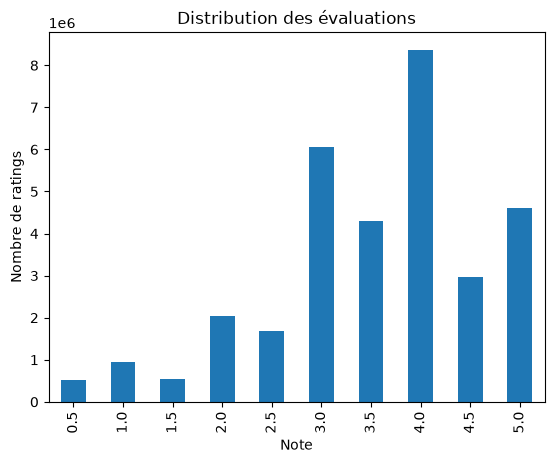

In [46]:
# Distribution des ratings
ratings["rating"].value_counts().sort_index().plot(
    kind="bar"
)
plt.title("Distribution des ratings")
plt.xlabel("Note")
plt.ylabel("Nombre de ratings")
plt.show()

In [49]:
# Nombres uniques d'utilisateurs, de films et notations
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings = len(ratings)
n_tags = len(tags)

print(f"Nombre d'utilisateurs : {n_users:,}")
print(f"Nombre de films       : {n_movies:,}")
print(f"Nombre de ratings     : {n_ratings:,}")
print(f"Nombre de tags        : {n_tags:,}")

Nombre d'utilisateurs : 200,948
Nombre de films       : 84,432
Nombre de ratings     : 32,000,204
Nombre de tags        : 2,000,072


In [63]:
# Activité des utilisateurs (nombre total de films notés par utilisateur)
ratings_per_user = ratings.groupby("userId").size()

In [64]:
ratings_per_user.describe()

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
dtype: float64

In [65]:
ratings_per_user.sort_values(ascending=False).head(5)

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
dtype: int64

In [66]:
# Popularité des films
ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_movie.describe()
ratings_per_movie.sort_values(ascending=False).head(5)

movieId
318     102929
356     100296
296      98409
2571     93808
593      90330
dtype: int64

In [67]:
# Fusion des films et nombre de notes associées
movie_stats = (movies.merge(ratings_per_movie.rename("rating_count"), on="movieId",how="left"))

movie_stats["rating_count"] = movie_stats["rating_count"].fillna(0)
movie_stats.sort_values(
    "rating_count",
    ascending=False
).head(5)

,movieId,title,genres,rating_count
314,318,"Shawshank Redemption, The (1994)",Crime|Drama,102929.0
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,100296.0
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,98409.0
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,93808.0
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,90330.0


In [68]:
# Sparsité 
total_possible_interactions = n_users * n_movies

sparsity = 1 - (n_ratings / total_possible_interactions)

print(f"Sparsité : {sparsity:.2%}")

density = n_ratings / total_possible_interactions

print(f"Densité : {density:.2%}")

Sparsité : 99.81%
Densité : 0.19%


### Interprétation

La matrice utilisateur-film présente une densité très faible et justifie l'évaluation d'approches complémentaires,notamment basées sur le contenu.

## Qualité des données

In [74]:
# Valeurs manquantes

print("Valeurs manquantes movies")
print(movies.isna().sum())
print("###########################################")

print("Valeurs manquantes ratings")
print(ratings.isna().sum())
print("###########################################")

print("Valeurs manquantes tags")
print(tags.isna().sum())
print("###########################################")

print("Valeurs manquantes links")
print(links.isna().sum())

Valeurs manquantes movies
movieId    0
title      0
genres     0
dtype: int64
###########################################
Valeurs manquantes ratings
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
###########################################
Valeurs manquantes tags
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64
###########################################
Valeurs manquantes links
movieId      0
imdbId       0
tmdbId     124
dtype: int64


### Observation

Les jeux de données `movies` et `ratings` ne contiennent aucune valeur manquante.

Le jeu `tags` contient 17 valeurs manquantes dans la colonne `tag`, tandis que `links` contient 124 valeurs manquantes dans `tmdbId`.

Ces valeurs manquantes restent limitées et ne concernent pas les colonnes essentielles à l'identification des utilisateurs, des films ou aux évaluations. Elles ne constituent donc pas, à ce stade, un obstacle majeur pour l'analyse exploratoire.

In [81]:
# Doublons

print("###### Doublons des films ######")
print(movies.duplicated().sum())
print("###### Doublons des ratings ######")
print(ratings.duplicated().sum())
print("###### Doublons des tags ######")
print(tags.duplicated().sum())
print("###### Doublons des links ######")
print(links.duplicated().sum())

print("Doublons movieId dans movies :", movies["movieId"].duplicated().sum())
print("Doublons movieId + userId dans ratings :", 
      ratings.duplicated(subset=["userId", "movieId"]).sum())


###### Doublons des films ######
0
###### Doublons des ratings ######
0
###### Doublons des tags ######
0
###### Doublons des links ######
0
Doublons movieId dans movies : 0
Doublons movieId + userId dans ratings : 0


### Observation

Aucun doublon n'a été détecté dans les quatre jeux de données.
La colonne `movieId` est également unique dans `movies`, et aucun couple `(userId, movieId)` n'est dupliqué dans `ratings`.

In [82]:
# Validité des ratings: Nous vérifions que les notes attribuées par 
# les utilisateurs respectent l'échelle utilisée par MovieLens.

print("Note minimale :", ratings["rating"].min())
print("Note maximale :", ratings["rating"].max())
print("Notes uniques :", sorted(ratings["rating"].unique()))

Note minimale : 0.5
Note maximale : 5.0
Notes uniques : [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [94]:
# Intégrité des moviesId et userId

movie_ids_movies = set(movies["movieId"])
movie_ids_ratings = set(ratings["movieId"])
ratings_movies_missing = movie_ids_ratings - movie_ids_movies
print("nombre de moviesId dans movies", len(movie_ids_movies))
print("nombre de moviesId dans ratings", len(movie_ids_ratings))
print("movieId présents dans ratings mais absents de movies :",
      len(ratings_movies_missing))

movies_without_ratings = movie_ids_movies - movie_ids_ratings

print("\nFilms présents dans movies mais sans aucun rating :",
      len(movies_without_ratings))

print("Nombre d'utilisateurs dans ratings :", ratings["userId"].nunique())
print("Nombre de userId invalides :", ratings["userId"].isna().sum())

nombre de moviesId dans movies 87585
nombre de moviesId dans ratings 84432
movieId présents dans ratings mais absents de movies : 0

Films présents dans movies mais sans aucun rating : 3153
Nombre d'utilisateurs dans ratings : 200948
Nombre de userId invalides : 0


In [95]:
quality_summary = pd.DataFrame({
    "Dataset": ["movies", "ratings", "tags", "links"],
    "Lignes": [
        len(movies),
        len(ratings),
        len(tags),
        len(links)
    ],
    "Valeurs_manquantes": [
        movies.isna().sum().sum(),
        ratings.isna().sum().sum(),
        tags.isna().sum().sum(),
        links.isna().sum().sum()
    ],
    "Doublons": [
        movies.duplicated().sum(),
        ratings.duplicated().sum(),
        tags.duplicated().sum(),
        links.duplicated().sum()
    ]
})

quality_summary

,Dataset,Lignes,Valeurs_manquantes,Doublons
0,movies,87585,0,0
1,ratings,32000204,0,0
2,tags,2000072,17,0
3,links,87585,124,0


## Analyse temporelle

In [97]:
# Évolution des évaluations dans le temps

ratings["rating_date"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

ratings[["timestamp", "rating_date"]].head()

,timestamp,rating_date
0,944249077,1999-12-03 19:24:37
1,944250228,1999-12-03 19:43:48
2,943230976,1999-11-22 00:36:16
3,944249077,1999-12-03 19:24:37
4,943228858,1999-11-22 00:00:58


In [101]:
# Période couverte par les ratings

print("Première évaluation :", ratings["rating_date"].min())
print("Dernière évaluation :", ratings["rating_date"].max())
print("\nDurée couverte :",
      ratings["rating_date"].max() - ratings["rating_date"].min())

Première évaluation : 1995-01-09 11:46:44
Dernière évaluation : 2023-10-13 02:29:07

Durée couverte : 10503 days 14:42:23


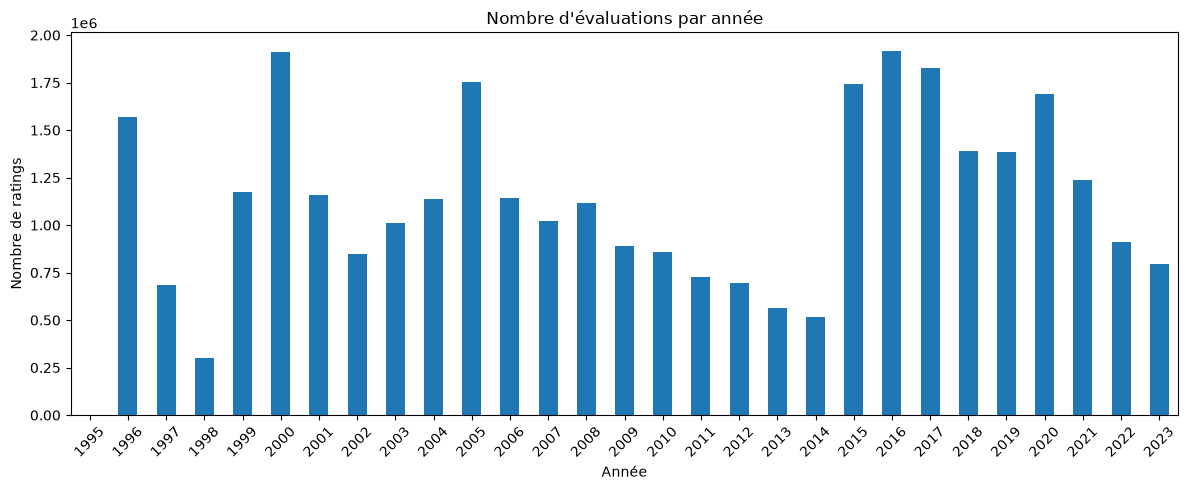

In [108]:
# Nombre de ratings par années

ratings_per_year = (ratings.groupby(ratings["rating_date"].dt.year).size())

plt.figure(figsize=(12, 5))

ratings_per_year.plot(kind="bar")

plt.title("Nombre d'évaluations par année")
plt.xlabel("Année")
plt.ylabel("Nombre de ratings")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Les évaluations couvrent la période allant du 9 janvier 1995 au 13 octobre 2023, soit près de 29 années de données.

Le nombre d'évaluations varie fortement au cours du temps. Plusieurs périodes présentent une activité particulièrement élevée, notamment autour de 2000, 2005 et entre 2015 et 2017. À l'inverse, une diminution progressive du nombre de ratings est observée sur plusieurs périodes, notamment entre 2010 et 2014 ainsi qu'après 2017.

Cette évolution temporelle montre que l'activité des utilisateurs n'est pas constante. Elle pourra être prise en compte ultérieurement dans la conception et l'évaluation du système de recommandation, notamment pour analyser l'évolution des préférences des utilisateurs et éventuellement considérer la récence des évaluations.

In [114]:
# nombre de ratings par mois

ratings_per_month = ratings.groupby(ratings["rating_date"].dt.to_period("M")).size()
ratings_per_month.head(10)



rating_date
1995-01         4
1996-01        42
1996-02       449
1996-03      9184
1996-04     51197
1996-05    181762
1996-06    254261
1996-07    216201
1996-08    209688
1996-09    146852
Freq: M, dtype: int64

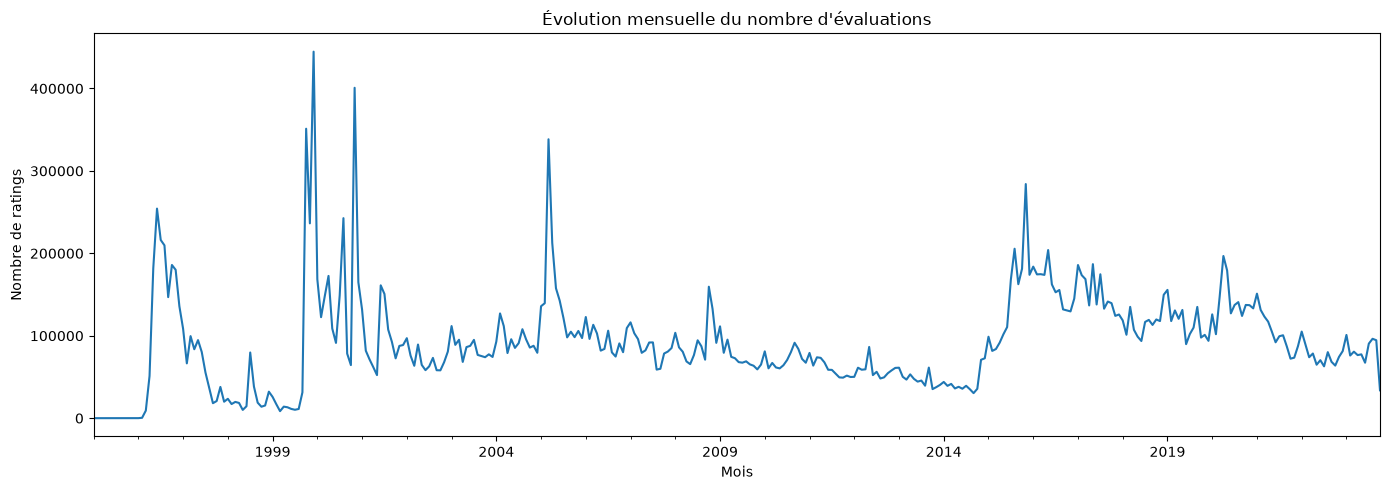

In [115]:
plt.figure(figsize=(14, 5))

ratings_per_month.plot()

plt.title("Évolution mensuelle du nombre d'évaluations")
plt.xlabel("Mois")
plt.ylabel("Nombre de ratings")
plt.tight_layout()

plt.show()

## Analyse des genres de films

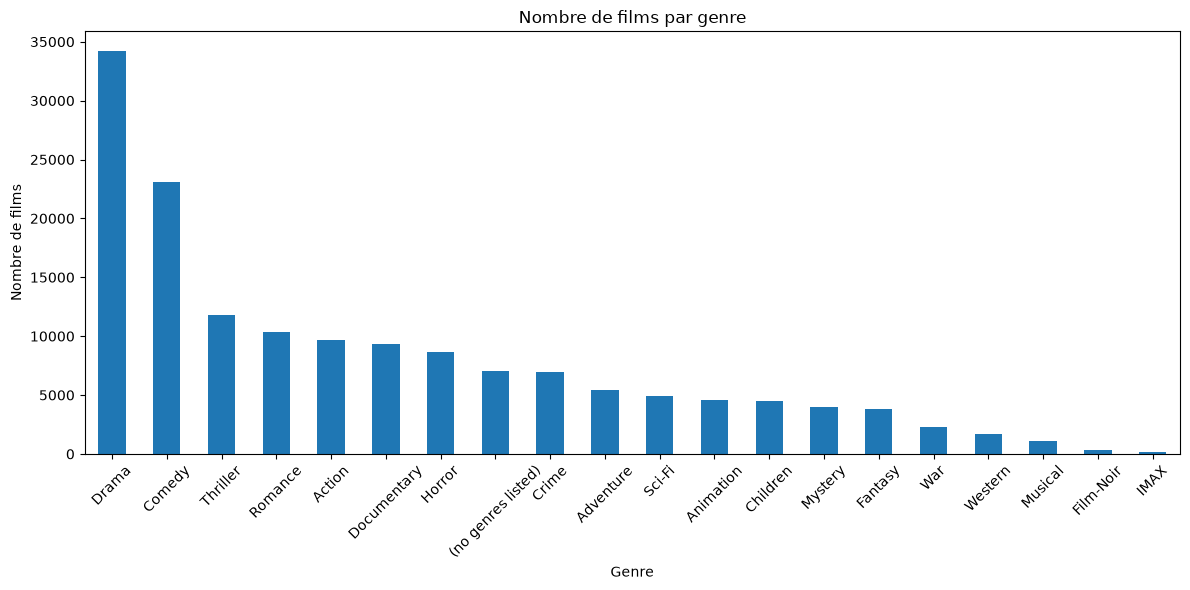

In [118]:
genres = (
    movies["genres"]
    .str.split("|")
    .explode()
)

genre_counts = genres.value_counts()

plt.figure(figsize=(12, 6))

genre_counts.plot(kind="bar")

plt.title("Nombre de films par genre")
plt.xlabel("Genre")
plt.ylabel("Nombre de films")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Les genres ne sont pas répartis uniformément dans le catalogue MovieLens.

Certains genres, notamment Drama, Comedy, Thriller et Romance, regroupent une part importante des films disponibles, tandis que d'autres catégories sont beaucoup moins représentées.

Un même film pouvant appartenir à plusieurs genres, le nombre total d'occurrences de genres est supérieur au nombre total de films.

Cette information sera utile pour les approches de recommandation basées sur le contenu, car les genres constituent une première source de caractéristiques permettant de mesurer la similarité entre les films.

In [119]:
# Statistiques de notation par film

movie_rating_stats = (
    ratings
    .groupby("movieId")
    .agg(
        rating_count=("rating", "count"),
        rating_mean=("rating", "mean")
    )
    .reset_index()
)

movie_rating_stats.head()

,movieId,rating_count,rating_mean
0,1,68997,3.897438
1,2,28904,3.275758
2,3,13134,3.139447
3,4,2806,2.845331
4,5,13154,3.059602


In [121]:
# Association avec les titres des films

movie_rating_stats = movie_rating_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

movie_rating_stats.sort_values(
    "rating_count",
    ascending=False
).head(5)

,movieId,rating_count,rating_mean,title_x,genres_x,title_y,genres_y
314,318,102929,4.404614,"Shawshank Redemption, The (1994)",Crime|Drama,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,100296,4.052744,Forrest Gump (1994),Comedy|Drama|Romance|War,Forrest Gump (1994),Comedy|Drama|Romance|War
292,296,98409,4.196969,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
2480,2571,93808,4.156437,"Matrix, The (1999)",Action|Sci-Fi|Thriller,"Matrix, The (1999)",Action|Sci-Fi|Thriller
585,593,90330,4.148367,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller


In [124]:
# Films les mieux notés parmi les films suffisamment populaires

MIN_RATINGS = 1000

top_rated_movies = (
    movie_rating_stats[
        movie_rating_stats["rating_count"] >= MIN_RATINGS
    ]
    .sort_values(
        ["rating_mean", "rating_count"],
        ascending=[False, False]
    )
)
top_rated_movies[
    ["title_x", "rating_mean", "rating_count"]
].head(5)

,title_x,rating_mean,rating_count
44190,Planet Earth II (2016),4.446830,1956
39306,Planet Earth (2006),4.444369,2948
44042,Band of Brothers (2001),4.426539,2811
314,"Shawshank Redemption, The (1994)",4.404614,102929
840,"Godfather, The (1972)",4.317030,66440


### Observation

La note moyenne seule n'est pas suffisante pour évaluer la popularité ou l'intérêt potentiel d'un film.

Certains films peuvent obtenir une moyenne très élevée avec un nombre limité d'évaluations. Pour réduire cet effet, nous avons filtré les films possédant au moins 1 000 ratings avant de comparer leurs notes moyennes.

Cette distinction entre **popularité** et **appréciation moyenne** sera importante lors de la construction de notre premier modèle de recommandation basé sur la popularité.

# Conclusion de l'analyse exploratoire

L'exploration du jeu de données MovieLens 32M met en évidence plusieurs caractéristiques importantes pour la conception du système de recommandation.

### Principaux constats

- Le dataset contient environ **32 millions d'évaluations**, provenant de plus de **200 000 utilisateurs**.
- Plus de **84 000 films** apparaissent dans les interactions utilisateurs.
- Les notes sont comprises entre **0.5 et 5.0**, avec une moyenne d'environ **3.54**.
- Chaque utilisateur possède au minimum 20 évaluations, mais l'activité varie fortement d'un utilisateur à l'autre.
- La popularité des films est également très déséquilibrée : certains films disposent de plus de 100 000 évaluations tandis que d'autres en possèdent très peu.
- La matrice utilisateur-film est extrêmement creuse, avec une sparsité d'environ **99.81 %**.
- Les données principales (`movies` et `ratings`) présentent une bonne qualité générale : aucune valeur manquante ni interaction utilisateur-film dupliquée.
- Plusieurs milliers de films du catalogue ne possèdent aucune évaluation.
- Les interactions couvrent près de 29 années, ce qui introduit une dimension temporelle potentiellement utile.
- Les genres sont fortement déséquilibrés mais fournissent des informations exploitables pour une approche basée sur le contenu.

### Conséquences pour la modélisation

Ces observations orientent la suite du projet vers plusieurs approches complémentaires :

1. un **modèle basé sur la popularité**, servant de baseline ;
2. un **système basé sur le contenu**, exploitant notamment les genres et éventuellement les tags ;
3. un **modèle de filtrage collaboratif**, exploitant les interactions utilisateur-film ;
4. une combinaison de ces approches dans un **système hybride**.

La forte sparsité de la matrice utilisateur-film et l'existence de films peu ou pas évalués devront être prises en compte lors de la préparation des données et de l'évaluation des modèles.